In [6]:
from inspect import getsourcefile
from pathlib import Path

import numpy as np
from daceypy import DA, array
from daceypy.op import cos, exp, sin, sqr

In [7]:
#Ex 5.1.1 : compute 2 tangent vectors as well as the normal vector of a surfacers and 1 normal vector of a given surgace

def f(x):
    return -0.3 * (x[0]**2 + x[1]**2/2) + 0.8*exp(x[0]/2 + x[1]/4)
order = 20

DA.init(order,2)
s1 = DA(1)
s2 = DA(2)
surf = array([s1,s2,f([s1,s2])])

t1 = surf.deriv(1)
t2 = surf.deriv(2)
n = t1.cross(t2)






In [8]:
#Ex 5.1.2 Implement the Equations of motion of an uncontrolled inverted pendulum as an algebraic vector

def ode_pen(x,y):
    L = 1.0
    m = 0.1
    M = 0.4
    g = 9.81

    sint = sin(x)
    cost = cos(y)

    return y, ((M+m)*g*sint-m*L*sqr(y)*sint*cost)/((M+m)*L+m*L*sqr(cost))

x, y = 1.0, 0.0

print(ode_pen(x,y))

(0.0, np.float64(6.879025300804555))


In [ ]:
#Ex: 5.2.1 Solar Flux.
# f(x,y) of uncontrolled pendulum used with a domain of [-1,1]^2 use to model surface.
#Calculate the heat of different parts when heat shining along z axis
#Make a solar intesnity plot

s1 = DA(1)
s2 = DA(2)
surf = array([s1,s2,f([s1,s2])])
t1 = surf.deriv(1).normalize()
t2 = surf.deriv(2).normalize()
n = t1.cross(t2).normalize()
sun = [0.0, 0.0, 1.0]

flux = 1400 * n.dot(sun)
print(flux)

N = 30
arg = np.array([0.0,0.0])
res = np.array([0.0,0.0,0.0])
res_points = []
flux_points = []

for i in range(-N,N+1):
    for j in range(-N,N+1):
        arg[0] = i/N
        arg[1] = j/N
        res_points = res_points.append.surf.eval(arg)
        flux_points = flux_points.append.flux.eval(arg)





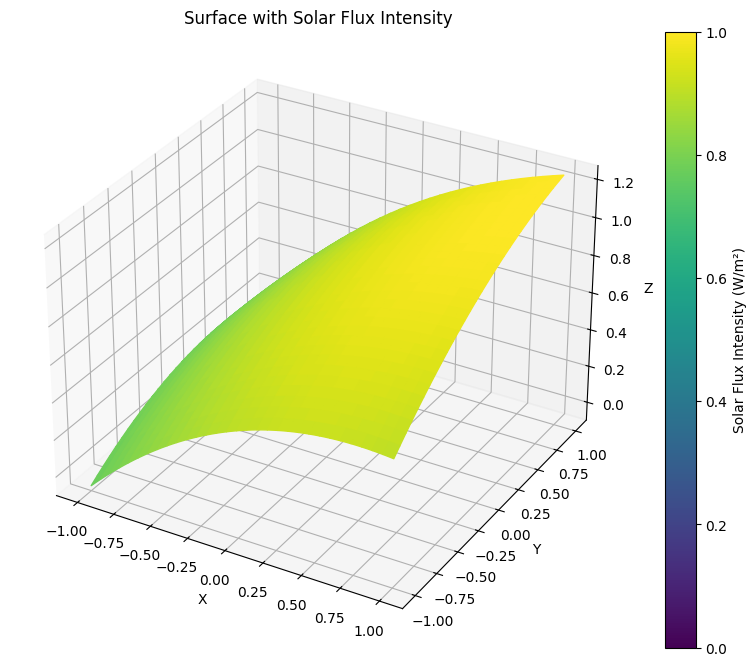

In [9]:
import numpy as np
from daceypy import DA, array
from daceypy.op import cos, exp, sin, sqr
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x):
    return -0.3 * (x[0]**2 + x[1]**2/2) + 0.8*exp(x[0]/2 + x[1]/4)

# DA initialization and surface calculation
order = 20
DA.init(order, 2)
s1 = DA(1)
s2 = DA(2)
surf = array([s1, s2, f([s1, s2])])
t1 = surf.deriv(1).normalize()
t2 = surf.deriv(2).normalize()
n = t1.cross(t2).normalize()
sun = [0.0, 0.0, 1.0]

flux = 1400 * n.dot(sun)

# Sampling points
N = 30
x = np.linspace(-1, 1, 2*N+1)
y = np.linspace(-1, 1, 2*N+1)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
flux_values = np.zeros_like(X)

# Calculate surface points and flux values
for i in range(2*N+1):
    for j in range(2*N+1):
        arg = np.array([X[i,j], Y[i,j]])
        # Evaluate the surface
        surf_point = surf.eval(arg)
        Z[i,j] = surf_point[2]
        # Evaluate the flux
        flux_values[i,j] = flux.eval(arg)

# Create the solar intensity plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with flux intensity as colors
surf_plot = ax.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(flux_values/np.max(flux_values)),
                          cmap='viridis')

# Add a color bar
fig.colorbar(surf_plot, ax=ax, label='Solar Flux Intensity (W/m²)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Surface with Solar Flux Intensity')

plt.show()

In [ ]:
#Ex 5.2.2

